# Tabular EDA — Used-Car Prices, Mileage, and Vehicle Cohorts

This notebook provides a table-first overview of the six Parquet datasets. It adds compact variable guides and basic profiles for all documented columns, then examines `used_cars.price` and `used_cars.mileage` and their averages by vPIC vehicle cohort. It retains the existing price/mileage histograms and cohort charts; the new additions are tables only.

A vehicle **cohort** is the combination of `ModelYear`, `Make`, `Model`, and `Trim` from `NHTSA_vPIC`. The four cohort dimensions remain separate columns. Used-car listings join to the lowercase vPIC `vin` field; the capitalized `VIN` decoder-variable column is not a join key.


## 1. Setup and source inventory

The Parquet mapping follows `EDA/DATA_CLEANING.py`. The dictionary supplies documented meaning, storage type, classification, missing-value profile, distinct count, and examples. The tables below add practical EDA guidance for each field without asserting undocumented source semantics.


In [34]:
from pathlib import Path
import html
import re
import textwrap

import numpy as np
import pandas as pd
import polars as pl
import pyarrow.parquet as pq
from IPython.display import HTML, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "DATA_DICTIONARY.md").exists():
    PROJECT_ROOT = Path("..").resolve()
DATASET_DIR = PROJECT_ROOT / "DATA" / "CAR_DATA_FINAL"
DICTIONARY_PATH = PROJECT_ROOT / "DATA_DICTIONARY.md"
MAX_PLOT_ROWS = 200_000
TABLE_FILES = {
    "used_cars": "used_cars.parquet",
    "NHTSA_vPIC": "NHTSA_vPIC.parquet",
    "NHTSA_Complaints": "NHTSA_Complaints.parquet",
    "NHTSA_Recalls": "NHTSA_Recalls.parquet",
    "NHTSA_Safety": "NHTSA_Safety.parquet",
    "Youtube_Comments": "Youtube_Comments.parquet",
}

if not DICTIONARY_PATH.is_file():
    raise FileNotFoundError(f"Data dictionary not found: {DICTIONARY_PATH}")
missing_files = [filename for filename in TABLE_FILES.values() if not (DATASET_DIR / filename).is_file()]
if missing_files:
    raise FileNotFoundError(f"Missing Parquet file(s) under {DATASET_DIR}: {missing_files}")
print(f"Project: {PROJECT_ROOT}\nParquet snapshot: {DATASET_DIR}")


Project: E:\DataScience_Capstone_Cars
Parquet snapshot: E:\DataScience_Capstone_Cars\DATA\CAR_DATA_FINAL


## 2. Dataset inventory

Start with table grain and size before comparing variables across sources. The row-grain descriptions come from `DATA_DICTIONARY.md`; row and column counts are read from the Parquet files.


In [35]:
dictionary_text = DICTIONARY_PATH.read_text(encoding="utf-8")

def parse_dictionary(path_text: str) -> tuple[dict[str, dict[str, dict[str, str]]], dict[str, str]]:
    """Read documented field metadata and each table's stated row grain."""
    fields_by_table = {}
    grain_by_table = {}
    active_table = None
    for line in path_text.splitlines():
        heading = re.match(r"^## `([^`]+)`\s*$", line)
        if heading:
            active_table = heading.group(1)
            fields_by_table.setdefault(active_table, {})
            continue
        if active_table is None:
            continue
        if active_table not in grain_by_table and line.strip() and not line.startswith("|"):
            grain_by_table[active_table] = re.sub(r"\s*\*\*[^*]+\*\*\.?$", "", line.strip())
        if not line.startswith("|") or "---" in line:
            continue
        parts = [part.strip() for part in line.strip().strip("|").split("|")]
        if len(parts) >= 8 and parts[0].strip("`") not in {"Column", ""}:
            column = parts[0].strip("`")
            fields_by_table[active_table][column] = {
                "Storage type": parts[1].strip("`") ,
                "Classification": parts[2],
                "Documented meaning": parts[3],
                "Missing values": parts[4],
                "Rows with values": parts[5],
                "Distinct values": parts[6],
                "Examples": parts[7],
            }
    return fields_by_table, grain_by_table

field_metadata, table_grain = parse_dictionary(dictionary_text)
inventory_rows = []
for table_name, filename in TABLE_FILES.items():
    metadata = pq.ParquetFile(DATASET_DIR / filename).metadata
    inventory_rows.append({
        "Table": table_name,
        "Parquet file": filename,
        "Rows": metadata.num_rows,
        "Columns": metadata.num_columns,
        "Row grain": table_grain.get(table_name, "See dictionary for source grain."),
    })
inventory = pd.DataFrame(inventory_rows)
display(inventory.style.format({"Rows": "{:,.0f}", "Columns": "{:,.0f}"}))


,Table,Parquet file,Rows,Columns,Row grain
0,used_cars,used_cars.parquet,"3,000,000",59,One source listing row.
1,NHTSA_vPIC,NHTSA_vPIC.parquet,"2,999,875",133,One source VIN/model-year-hint decode row.
2,NHTSA_Complaints,NHTSA_Complaints.parquet,"1,390,528",17,One query/record-key complaint record; top-level JSON keys are separate columns.
3,NHTSA_Recalls,NHTSA_Recalls.parquet,"26,993",20,One query/record-key recall record; top-level JSON keys are separate columns.
4,NHTSA_Safety,NHTSA_Safety.parquet,"8,144",35,One query/vehicle-variant pair; rating fields are wide columns.
5,Youtube_Comments,Youtube_Comments.parquet,"1,981,686",12,One imported YouTube comment record.


## 3. Field guide for all tables

Each collapsible table includes the documented definition and observed profile from the dictionary, plus a new **EDA handling note**. These notes explain which summaries are useful for the variable's statistical role; they are guidance, not new claims about NHTSA or source-system semantics. Open a dataset section to review its columns.


In [36]:
def clean_examples(raw: str, max_examples: int = 2, max_chars: int = 90) -> str:
    text = html.unescape(raw).replace("<br>", " | ").replace("<br/>", " | ")
    text = re.sub(r"</?code>", "", text)
    values = [value.strip() for value in text.split("|") if value.strip()]
    if not values or values == ["—"]:
        return "—"
    shortened = [value if len(value) <= max_chars else value[:max_chars - 1] + "…" for value in values[:max_examples]]
    return " | ".join(shortened)

def handling_note(classification: str, storage_type: str) -> str:
    category = classification.lower()
    if category.startswith("identifier"):
        return "Use for record linkage or deduplication; do not summarize as a measured quantity."
    if category.startswith("temporal"):
        return "Check parsing, range, and time grain; keep calendar years distinct from continuous measures."
    if category.startswith("quantitative"):
        return "Check missingness, range, skew, and robust summaries (median and quartiles); confirm units."
    if category.startswith("categorical: ordinal"):
        return "Preserve documented order and any status values; do not assume equal numeric spacing."
    if category.startswith("categorical"):
        return "Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
    if category.startswith("text"):
        return "Inspect a small sample and missingness; extract structured features only for a defined question."
    if category.startswith("reference"):
        return "Treat as a reference link; check availability or domain only if relevant to the analysis."
    return f"Meaning is not fully specified; inspect values and source metadata before modeling ({storage_type})."

def make_field_guide(table_name: str) -> pd.DataFrame:
    rows = []
    for column, info in field_metadata.get(table_name, {}).items():
        missing = pd.to_numeric(info["Missing values"].replace(",", ""), errors="coerce")
        total_with_values = pd.to_numeric(info["Rows with values"].replace(",", ""), errors="coerce")
        total_rows = missing + total_with_values
        rows.append({
            "Column": column,
            "Storage type": info["Storage type"],
            "Variable role": info["Classification"],
            "Documented meaning": html.unescape(re.sub(r"</?code>", "", info["Documented meaning"])),
            "Missing rows": missing,
            "Missing %": (missing / total_rows) if total_rows and pd.notna(total_rows) else np.nan,
            "Distinct values": info["Distinct values"],
            "Examples": clean_examples(info["Examples"]),
            "EDA handling note": handling_note(info["Classification"], info["Storage type"]),
        })
    return pd.DataFrame(rows)

field_guides = {name: make_field_guide(name) for name in TABLE_FILES}
role_summary = (pd.concat([guide.assign(Table=name) for name, guide in field_guides.items()])
                .groupby(["Table", "Variable role"], dropna=False).size()
                .rename("Field count").reset_index())
display(role_summary.pivot(index="Table", columns="Variable role", values="Field count").fillna(0).astype(int))

for table_name, guide in field_guides.items():
    table_html = guide.to_html(index=False, escape=True, formatters={
        "Missing rows": lambda value: "—" if pd.isna(value) else f"{value:,.0f}",
        "Missing %": lambda value: "—" if pd.isna(value) else f"{value:.1%}",
    })
    section_html = (
        f"<details><summary><strong>{html.escape(table_name)}</strong> — {len(guide)} fields</summary>"
        f"<div style='overflow-x:auto'>{table_html}</div></details>"
    )
    display(HTML(section_html))


Variable role,Categorical: binary nominal,Categorical: nominal,"Categorical: nominal, multiple labels",Categorical: ordinal,Categorical: ordinal + status,Identifier: nominal,Quantitative: continuous,Quantitative: discrete,Reference: URL,Temporal: date/time,Temporal: discrete year (interval),Text / structured text
Table,,,,,,,,,,,,
NHTSA_Complaints,2,6,0,0,0,2,0,3,0,0,1,3
NHTSA_Recalls,2,6,0,0,0,3,0,0,0,2,2,5
NHTSA_Safety,0,11,0,0,13,2,0,3,6,0,0,0
NHTSA_vPIC,0,88,0,0,0,3,13,23,0,0,1,5
Youtube_Comments,0,3,0,0,0,3,0,2,0,3,0,1
used_cars,10,17,1,1,0,3,15,6,0,1,1,4


Column,Storage type,Variable role,Documented meaning,Missing rows,Missing %,Distinct values,Examples,EDA handling note
vin,String,Identifier: nominal,Source identifier `vin`; treat as a key rather than a numeric quantity.,0,0.0%,"3,000,000",ZACNJABB5KPJ92081 | SALCJ2FX1LH858117,Use for record linkage or deduplication; do not summarize as a measured quantity.
back_legroom,Float64,Quantitative: continuous,Numeric source field `back_legroom`; storage type is `Float64`.,"242,724",8.1%,218,35.1 | 38.1,"Check missingness, range, skew, and robust summaries (median and quartiles); confirm units."
bed,String,Categorical: ordinal,Source-provided `bed` value from `used_cars`; exact meaning follows the upstream field definition.,"2,980,432",99.3%,3,Short | Long,Preserve documented order and any status values; do not assume equal numeric spacing.
bed_length,Float64,Quantitative: continuous,Numeric source field `bed_length`; storage type is `Float64`.,"2,579,826",86.0%,82,78.9 | 81.9,"Check missingness, range, skew, and robust summaries (median and quartiles); confirm units."
body_type,String,Categorical: nominal,Source-provided `body_type` value from `used_cars`; exact meaning follows the upstream field definition.,"13,542",0.5%,9,SUV / Crossover | Sedan,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
cabin,String,Categorical: nominal,Source-provided `cabin` value from `used_cars`; exact meaning follows the upstream field definition.,"2,936,468",97.9%,4,Crew Cab | Extended Cab,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
city,String,Categorical: nominal,Source-provided `city` value from `used_cars`; exact meaning follows the upstream field definition.,0,0.0%,"4,687",Bayamon | San Juan,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
city_fuel_economy,Float64,Quantitative: continuous,Numeric source field `city_fuel_economy`; storage type is `Float64`.,"491,278",16.4%,100,17.0 | 22.0,"Check missingness, range, skew, and robust summaries (median and quartiles); confirm units."
daysonmarket,Int64,Quantitative: discrete,Source numeric measure in `daysonmarket`; storage type is `Int64`.,0,0.0%,"1,754",522 | 207,"Check missingness, range, skew, and robust summaries (median and quartiles); confirm units."
dealer_zip,Int64,Quantitative: discrete,Source numeric measure in `dealer_zip`; storage type is `Int64`.,209,0.0%,"8,234",960 | 922,"Check missingness, range, skew, and robust summaries (median and quartiles); confirm units."


Column,Storage type,Variable role,Documented meaning,Missing rows,Missing %,Distinct values,Examples,EDA handling note
vin,String,Identifier: nominal,"vPIC decoded field `vin`; consult the NHTSA variable metadata for its official label, ID, group, and data type.",0,0.0%,"2,999,875",00000000011111111 | 00000000011615922,Use for record linkage or deduplication; do not summarize as a measured quantity.
model_year_hint,Int64,Identifier: nominal,"vPIC decoded field `model_year_hint`; consult the NHTSA variable metadata for its official label, ID, group, and data type.",0,0.0%,98,1967 | 1925,Use for record linkage or deduplication; do not summarize as a measured quantity.
fetched_at,"Datetime(time_unit='us', time_zone=None)",Categorical: nominal,"vPIC decoded field `fetched_at`; consult the NHTSA variable metadata for its official label, ID, group, and data type.",0,0.0%,"34,268",2026-09-25 20:29:15 | 2026-09-25 20:29:16,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
ABS,String,Categorical: nominal,NHTSA variable `ABS`; label: Antilock Braking System (ABS); variable ID: 86; group: Active Safety System; DataType: `lookup`; stored in Parquet as `String`. See the [NHTSA variable list](https://vpic.nhtsa.dot.gov/api/vehicles/GetVehicleVariableList?format=json).,"1,057,509",35.3%,3,Not Applicable | Standard,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
ActiveSafetySysNote,String,Text / structured text,NHTSA variable `ActiveSafetySysNote`; label: Active Safety System Note; variable ID: 169; group: Active Safety System; DataType: `string`; stored in Parquet as `String`. See the [NHTSA variable list](https://vpic.nhtsa.dot.gov/api/vehicles/GetVehicleVariableList?format=json).,"2,774,053",92.5%,499,"Lane Keep System, Lane Departure Warning, Forward Collision Warning, Crash Imminent Braki… | Acura Watch Plus: Lane Keep System, Lane Departure Warning, Forward Collision Warning, Cr…",Inspect a small sample and missingness; extract structured features only for a defined question.
AdaptiveCruiseControl,String,Categorical: nominal,NHTSA variable `AdaptiveCruiseControl`; label: Adaptive Cruise Control (ACC); variable ID: 81; group: Active Safety System/Maintaining Safe Distance; DataType: `lookup`; stored in Parquet as `String`. See the [NHTSA variable list](https://vpic.nhtsa.dot.gov/api/vehicles/GetVehicleVariableList?format=json).,"2,137,888",71.3%,4,Not Applicable | Standard,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
AdaptiveDrivingBeam,String,Categorical: nominal,NHTSA variable `AdaptiveDrivingBeam`; label: Adaptive Driving Beam (ADB); variable ID: 180; group: Active Safety System/Lighting Technologies; DataType: `lookup`; stored in Parquet as `String`. See the [NHTSA variable list](https://vpic.nhtsa.dot.gov/api/vehicles/GetVehicleVariableList?format=json).,"2,432,288",81.1%,4,Not Applicable | Standard,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
AdaptiveHeadlights,String,Categorical: nominal,NHTSA variable `AdaptiveHeadlights`; label: AdaptiveHeadlights; variable ID: not captured; group: not captured; DataType: `None`; stored in Parquet as `String`. See the [NHTSA variable list](https://vpic.nhtsa.dot.gov/api/vehicles/GetVehicleVariableList?format=json).,"2,999,875",100.0%,0,—,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
AdditionalErrorText,String,Categorical: nominal,NHTSA variable `AdditionalErrorText`; label: Additional Error Text; variable ID: 156; group: not captured; DataType: `string`; stored in Parquet as `String`. See the [NHTSA variable list](https://vpic.nhtsa.dot.gov/api/vehicles/GetVehicleVariableList?format=json).,"2,519,979",84.0%,356,"Invalid character(s): 14:S, 15:V, 16:R, 17:A. | The Model Year decoded for this VIN may be incorrect. If you know the Model 

Column,Storage type,Variable role,Documented meaning,Missing rows,Missing %,Distinct values,Examples,EDA handling note
query_id,Int64,Identifier: nominal,"Source or project identifier `query_id`; use as a key, not a numeric measure.",0,0.0%,"6,707",9989 | 11348,Use for record linkage or deduplication; do not summarize as a measured quantity.
record_key,String,Identifier: nominal,"Source or project identifier `record_key`; use as a key, not a numeric measure.",0,0.0%,"5,128",0 | 1,Use for record linkage or deduplication; do not summarize as a measured quantity.
model_year,Int64,Temporal: discrete year (interval),Model or product year reported in `model_year`; retained as an interval year.,0,0.0%,60,2000 | 2002,"Check parsing, range, and time grain; keep calendar years distinct from continuous measures."
make,String,Categorical: nominal,Source NHTSA record field `make`; local query context and returned record fields can have different meanings.,0,0.0%,62,Toyota | Mercedes-Benz,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
model,String,Categorical: nominal,Source NHTSA record field `model`; local query context and returned record fields can have different meanings.,0,0.0%,917,MR2 Spyder | C-Class,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
components,String,Text / structured text,NHTSA narrative or structured source field `components`; extract features explicitly before modeling.,0,0.0%,"9,114",ENGINE AND ENGINE COOLING | STRUCTURE,Inspect a small sample and missingness; extract structured features only for a defined question.
crash,Boolean,Categorical: binary nominal,Boolean status returned in `crash`.,0,0.0%,2,False | True,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
dateComplaintFiled,String,Categorical: nominal,Source NHTSA record field `dateComplaintFiled`; local query context and returned record fields can have different meanings.,0,0.0%,"11,691",01/15/2004 | 11/24/2002,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
dateOfIncident,String,Categorical: nominal,Source NHTSA record field `dateOfIncident`; local query context and returned record fields can have different meanings.,"54,591",3.9%,"12,916",08/15/2003 | 11/15/2002,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
fire,Boolean,Categorical: binary nominal,Boolean status returned in `fire`.,0,0.0%,2,False | True,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."


Column,Storage type,Variable role,Documented meaning,Missing rows,Missing %,Distinct values,Examples,EDA handling note
query_id,Int64,Identifier: nominal,"Source or project identifier `query_id`; use as a key, not a numeric measure.",0,0.0%,"6,606",1114 | 1294,Use for record linkage or deduplication; do not summarize as a measured quantity.
record_key,String,Identifier: nominal,"Source or project identifier `record_key`; use as a key, not a numeric measure.",0,0.0%,33,0 | 1,Use for record linkage or deduplication; do not summarize as a measured quantity.
model_year,Int64,Temporal: discrete year (interval),Model or product year reported in `model_year`; retained as an interval year.,0,0.0%,60,1961 | 1963,"Check parsing, range, and time grain; keep calendar years distinct from continuous measures."
make,String,Categorical: nominal,Source NHTSA record field `make`; local query context and returned record fields can have different meanings.,0,0.0%,68,Chevrolet | Buick,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
model,String,Categorical: nominal,Source NHTSA record field `model`; local query context and returned record fields can have different meanings.,0,0.0%,912,Corvair | Wildcat,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
Component,String,Text / structured text,NHTSA narrative or structured source field `Component`; extract features explicitly before modeling.,0,0.0%,396,VISIBILITY:DEFROSTER/DEFOGGER/HVAC SYSTEM | VEHICLE SPEED CONTROL,Inspect a small sample and missingness; extract structured features only for a defined question.
Consequence,String,Text / structured text,NHTSA narrative or structured source field `Consequence`; extract features explicitly before modeling.,844,3.1%,"4,663","UNDER THESE CONDITIONS, VEHICLE OCCUPANTS MAY EXPERIENCECARBON MONOXIDE POISONING. | UNDER THESE CONDITIONS, THE VEHICLE OPERATOR MAY NOT BE ABLE TO STOP THE CAR, POSSIBLY RE…",Inspect a small sample and missingness; extract structured features only for a defined question.
Make,String,Categorical: nominal,Source NHTSA record field `Make`; local query context and returned record fields can have different meanings.,0,0.0%,68,CHEVROLET | BUICK,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
Manufacturer,String,Categorical: nominal,Source NHTSA record field `Manufacturer`; local query context and returned record fields can have different meanings.,0,0.0%,282,"GENERAL MOTORS CORP. | CARDONE INDUSTRIES, INC.","Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
Model,String,Categorical: nominal,Source NHTSA record field `Model`; local query context and returned record fields can have different meanings.,0,0.0%,912,CORVAIR | WILDCAT,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."


Column,Storage type,Variable role,Documented meaning,Missing rows,Missing %,Distinct values,Examples,EDA handling note
query_id,Int64,Identifier: nominal,Identifier for the query or NHTSA vehicle variant; retained as a linkage key.,0,0.0%,"5,460",5415 | 5421,Use for record linkage or deduplication; do not summarize as a measured quantity.
vehicle_id,String,Identifier: nominal,Identifier for the query or NHTSA vehicle variant; retained as a linkage key.,0,0.0%,"8,144",2860 | 2898,Use for record linkage or deduplication; do not summarize as a measured quantity.
ComplaintsCount,String,Quantitative: discrete,NHTSA reported count in `ComplaintsCount`; not VIN-specific.,4,0.0%,"1,017",94 | 43,"Check missingness, range, skew, and robust summaries (median and quartiles); confirm units."
FrontCrashDriversideRating,String,Categorical: ordinal + status,NHTSA safety rating field `FrontCrashDriversideRating`; values remain source text and may include statuses such as `Not Rated`.,"2,617",32.1%,5,5 | 1,Preserve documented order and any status values; do not assume equal numeric spacing.
FrontCrashPassengersideRating,String,Categorical: ordinal + status,NHTSA safety rating field `FrontCrashPassengersideRating`; values remain source text and may include statuses such as `Not Rated`.,"2,650",32.5%,5,5 | 4,Preserve documented order and any status values; do not assume equal numeric spacing.
FrontCrashPicture,String,Reference: URL,NHTSA safety-test media link in `FrontCrashPicture`.,"4,565",56.1%,"2,712",https://static.nhtsa.gov/crashTest/images/1997/LeSabre.jpg | https://static.nhtsa.gov/crashTest/images/1997/deville_a.gif,Treat as a reference link; check availability or domain only if relevant to the analysis.
FrontCrashVideo,String,Reference: URL,NHTSA safety-test media link in `FrontCrashVideo`.,"5,220",64.1%,"2,120",https://static.nhtsa.gov/crashTest/videos/1995/camaro.wmv | https://static.nhtsa.gov/crashTest/videos/1995/caprice.wmv,Treat as a reference link; check availability or domain only if relevant to the analysis.
InvestigationCount,String,Quantitative: discrete,NHTSA reported count in `InvestigationCount`; not VIN-specific.,4,0.0%,20,3 | 9,"Check missingness, range, skew, and robust summaries (median and quartiles); confirm units."
Make,String,Categorical: nominal,NHTSA safety field `Make` retained as source text.,4,0.0%,53,CADILLAC | CHEVROLET,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
Model,String,Categorical: nominal,NHTSA safety field `Model` retained as source text.,4,0.0%,723,DEVILLE | BLAZER,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."


Column,Storage type,Variable role,Documented meaning,Missing rows,Missing %,Distinct values,Examples,EDA handling note
video_id,String,Identifier: nominal,YouTube video identifier associated with the comment.,0,0.0%,"4,224",-MXV5VjFV54 | JH300fr1KO4,Use for record linkage or deduplication; do not summarize as a measured quantity.
playlist_id,String,Identifier: nominal,YouTube playlist identifier associated with the video.,0,0.0%,59,PLdmWqCdsjCu6XXTGcfwQE-v-8qZKOUbPv | PLdmWqCdsjCu4IAZtt7cFYCI-5wLOu-W5v,Use for record linkage or deduplication; do not summarize as a measured quantity.
video_title,String,Categorical: nominal,Title of the YouTube video associated with the comment.,0,0.0%,"4,223",2026 Dodge Charger Daytona Review | What Hellcat Fans Never Asked For (and that's a pity),"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
source,String,Categorical: nominal,Source label recorded by the importer.,0,0.0%,1,comment,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
text,String,Text / structured text,Comment text as imported; no sentiment score is calculated by this project.,94,0.0%,"1,942,766","About the efficiency, especially my comment around 35:00. The EPA's 72 MPGe rating isn't … | very nice car. i would never use the fake exhaust tho",Inspect a small sample and missingness; extract structured features only for a defined question.
extracted_at,String,Temporal: date/time,Date recorded when the comment was extracted; retained as source text.,0,0.0%,11,06-04-2026 | 06-08-2026,"Check parsing, range, and time grain; keep calendar years distinct from continuous measures."
comment_id,String,Identifier: nominal,YouTube comment identifier; source primary key.,0,0.0%,"1,981,686",UgzhGuCfKKwM7LgPkUN4AaABAg | Ugyf3dBDEdW_-rwDb194AaABAg,Use for record linkage or deduplication; do not summarize as a measured quantity.
author,String,Categorical: nominal,Comment author name as supplied by YouTube.,23,0.0%,"808,182",@AAutoBuyersGuide | @AntLive29,"Review missingness, distinct count, and common levels; group rare levels only with a stated rule."
like_count,Int64,Quantitative: discrete,Like count recorded for the comment.,0,0.0%,"3,450",22 | 27,"Check missingness, range, skew, and robust summaries (median and quartiles); confirm units."
reply_count,Int64,Quantitative: discrete,Reply count recorded for the comment.,0,0.0%,291,10 | 2,"Check missingness, range, skew, and robust summaries (median and quartiles); confirm units."


## 4. EDA principles used here

The notebook follows a table-first version of standard exploratory practice: understand the data grain, distinguish storage type from statistical role, check completeness and cardinality, and use robust numeric summaries before making modeling decisions. NIST describes EDA as a way to reveal structure, anomalies, and assumptions; pandas' descriptive summaries similarly separate numeric summaries from categorical counts.


In [37]:
eda_principles = pd.DataFrame([
    {"Principle": "Understand the row grain", "Applied here": "Inventory each source table separately; joins are explicit and keyed by lowercase vPIC vin."},
    {"Principle": "Separate storage type from variable role", "Applied here": "Field guide distinguishes numeric, categorical, ordinal, identifier, temporal, text, and reference fields."},
    {"Principle": "Check completeness and cardinality", "Applied here": "Field guide reports missing counts, missing rates, and distinct counts using the dictionary's documented profile rules."},
    {"Principle": "Use summaries suited to the variable", "Applied here": "Categorical fields get levels/examples; quantitative fields get counts, quartiles, median, mean, and range."},
    {"Principle": "Treat examples and inferred notes as descriptive", "Applied here": "Examples are short and illustrative; source definitions remain authoritative when available."},
    {"Principle": "Preserve measurement meaning", "Applied here": "IDs are not measures, ordinal ratings may contain statuses, and missing values are not assumed to mean zero."},
])
display(eda_principles)


,Principle,Applied here
0,Understand the row grain,Inventory each source table separately; joins ...
1,Separate storage type from variable role,"Field guide distinguishes numeric, categorical..."
2,Check completeness and cardinality,"Field guide reports missing counts, missing ra..."
3,Use summaries suited to the variable,Categorical fields get levels/examples; quanti...
4,Treat examples and inferred notes as descriptive,Examples are short and illustrative; source de...
5,Preserve measurement meaning,"IDs are not measures, ordinal ratings may cont..."


## 5. Focus profile: listing price and mileage

The next table gives descriptive summaries of `used_cars.price` and `used_cars.mileage`. The values are computed over all finite, nonnegative rows. Median and quartiles complement the mean because vehicle price and mileage can be skewed. No distribution charts are included at this stage.


In [38]:
used_cars_path = DATASET_DIR / TABLE_FILES["used_cars"]
used_cars = pl.scan_parquet(used_cars_path)
used_schema = used_cars.collect_schema()
focus_fields = ["price", "mileage"]
if any(field not in used_schema for field in focus_fields):
    raise KeyError("used_cars.parquet must contain both price and mileage")

summary_rows = []
for field, unit in [("price", "USD per listing"), ("mileage", "miles on odometer")]:
    value = pl.col(field).cast(pl.Float64, strict=False)
    valid = value.is_not_null() & value.is_finite() & (value >= 0)
    result = used_cars.select([
        valid.sum().alias("Valid rows"),
        (~valid).sum().alias("Excluded rows"),
        value.filter(valid).min().alias("Minimum"),
        value.filter(valid).quantile(0.25).alias("Q1"),
        value.filter(valid).median().alias("Median"),
        value.filter(valid).mean().alias("Mean"),
        value.filter(valid).quantile(0.75).alias("Q3"),
        value.filter(valid).quantile(0.995).alias("99.5th percentile"),
        value.filter(valid).max().alias("Maximum"),
    ]).collect().to_dicts()[0]
    result["Variable"] = field
    result["Unit / interpretation"] = unit
    summary_rows.append(result)
price_mileage_summary = pd.DataFrame(summary_rows).set_index("Variable")
display(price_mileage_summary.style.format({
    "Valid rows": "{:,.0f}", "Excluded rows": "{:,.0f}",
    "Minimum": "{:,.1f}", "Q1": "{:,.1f}", "Median": "{:,.1f}",
    "Mean": "{:,.1f}", "Q3": "{:,.1f}",
    "99.5th percentile": "{:,.1f}", "Maximum": "{:,.1f}",
}))


,Valid rows,Excluded rows,Minimum,Q1,Median,Mean,Q3,99.5th percentile,Maximum,Unit / interpretation
Variable,,,,,,,,,,
price,"3,000,000",0,165.0,"18,451.0","26,477.0","29,933.4","38,220.0","102,995.0","3,299,995.0",USD per listing
mileage,"2,855,613","144,387",0.0,6.0,"8,267.0","31,146.9","43,662.0","210,875.0","99,999,988.0",miles on odometer


The two existing histograms compare the original distribution with log1p so long right tails are easier to inspect. The original-scale panel shows values through the 99.5th percentile and reports the share above that display limit.

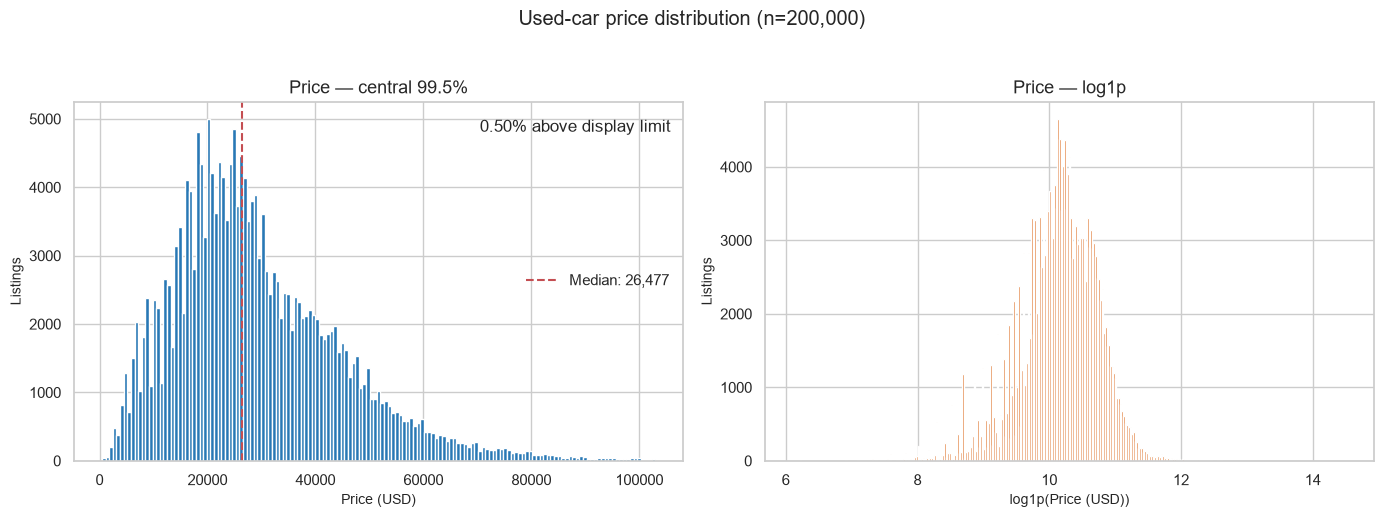

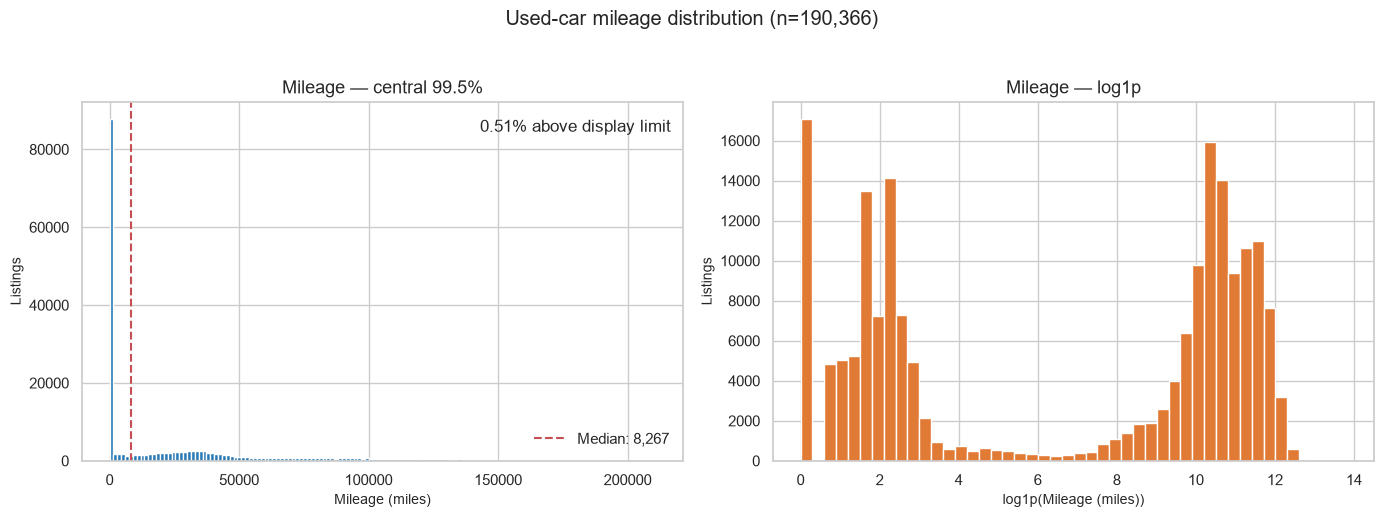

In [39]:
# Existing focused views: original-scale and log1p histograms for price and mileage.
for field, unit in [("price", "Price (USD)"), ("mileage", "Mileage (miles)")]:
    total_rows = int(pq.ParquetFile(used_cars_path).metadata.num_rows)
    stride = max(1, total_rows // MAX_PLOT_ROWS)
    values = (used_cars.with_row_index("_row_index")
              .filter((pl.col("_row_index") % stride) == 0)
              .select(pl.col(field).cast(pl.Float64, strict=False))
              .limit(MAX_PLOT_ROWS).collect().to_series().drop_nulls().to_numpy())
    values = values[np.isfinite(values) & (values >= 0)]
    if values.size == 0:
        print(f"{field}: no valid nonnegative observations to plot.")
        continue
    cutoff = float(price_mileage_summary.loc[field, "99.5th percentile"])
    central_values = values[values <= cutoff]
    tail_share = 1 - central_values.size / values.size
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(central_values, bins="auto", color="#2878B5", edgecolor="white")
    axes[0].axvline(price_mileage_summary.loc[field, "Median"], color="#C44E52", linestyle="--", label=f"Median: {price_mileage_summary.loc[field, 'Median']:,.0f}")
    axes[0].set(title=f"{field.title()} — central 99.5%", xlabel=unit, ylabel="Listings")
    axes[0].text(.98, .95, f"{tail_share:.2%} above display limit", transform=axes[0].transAxes, ha="right", va="top")
    axes[0].legend(frameon=False)
    axes[1].hist(np.log1p(values), bins="auto", color="#E07A35", edgecolor="white")
    axes[1].set(title=f"{field.title()} — log1p", xlabel=f"log1p({unit})", ylabel="Listings")
    fig.suptitle(f"Used-car {field} distribution (n={values.size:,})", y=1.03)
    plt.tight_layout(); plt.show()


## 6. Cohort averages as a table

A cohort is vPIC `ModelYear`, `Make`, `Model`, and `Trim`. All four dimensions remain separate in the result. The table is sorted by highest average price and includes average mileage and eligible listing count.


In [40]:
vpic_path = DATASET_DIR / TABLE_FILES["NHTSA_vPIC"]
vpic = pl.scan_parquet(vpic_path)
vpic_schema = vpic.collect_schema()
listing_fields = ["vin", "price", "mileage"]
vpic_fields = ["vin", "ModelYear", "Make", "Model", "Trim"]
missing_listing = [field for field in listing_fields if field not in used_schema]
missing_vpic = [field for field in vpic_fields if field not in vpic_schema]
if missing_listing or missing_vpic:
    raise KeyError(f"Missing cohort fields; used_cars={missing_listing}, NHTSA_vPIC={missing_vpic}")

# Join on lowercase `vin`; never use uppercase `VIN` decoder output for this join.
listing_rows = used_cars.select(
    pl.col("vin"),
    pl.col("price").cast(pl.Float64, strict=False).alias("price"),
    pl.col("mileage").cast(pl.Float64, strict=False).alias("mileage"),
)
vpic_rows = vpic.select(
    pl.col("vin"),
    pl.col("ModelYear").cast(pl.Int64, strict=False).alias("Year"),
    pl.col("Make"), pl.col("Model"), pl.col("Trim"),
)
cohort_averages = (
    listing_rows.join(vpic_rows, on="vin", how="inner", validate="m:1")
    .filter(
        pl.all_horizontal([pl.col(name).is_not_null() for name in ["Year", "Make", "Model", "Trim"]])
        & pl.col("price").is_finite() & (pl.col("price") >= 0)
        & pl.col("mileage").is_finite() & (pl.col("mileage") >= 0)
    )
    .group_by(["Year", "Make", "Model", "Trim"])
    .agg(
        pl.col("price").mean().alias("Average price (USD)"),
        pl.col("mileage").mean().alias("Average mileage (miles)"),
        pl.len().alias("Listing count"),
    )
    .sort("Average price (USD)", descending=True)
    .collect()
)
print(f"Eligible cohorts: {cohort_averages.height:,}")
display(cohort_averages.head(100).to_pandas().style.format({
    "Average price (USD)": "${:,.0f}",
    "Average mileage (miles)": "{:,.0f}",
    "Listing count": "{:,.0f}",
}))


Eligible cohorts: 14,275


,Year,Make,Model,Trim,Average price (USD),Average mileage (miles),Listing count
0,1988,PORSCHE,944,Turbo,"$1,425,000","34,449",1
1,2017,FORD,GT,RWD,"$1,150,000",517,3
2,2018,FORD,GT,RWD,"$999,800",623,2
3,2018,ASTON MARTIN,Vanquish Zagato,2+2 Seating Configuration,"$890,888",110,1
4,2005,PORSCHE,911,GT,"$809,720","2,199",4
5,2021,MERCEDES-BENZ,E-Class,E350,"$790,726",0,13
6,2020,LAMBORGHINI,Aventador,SVJ,"$689,948",280,2
7,2020,FORD,GT,Carbon Series GT,"$626,340",16,1
8,2020,ROLLS-ROYCE,Phantom,Phantom,"$532,893",153,5
9,2019,LAMBORGHINI,Aventador,SVJ,"$530,716","1,213",4


Cohort averages use matched listings with complete Year/Make/Model/Trim labels and finite nonnegative price and mileage. The join is validated as many listing rows to one vPIC row per lowercase VIN. The full result remains in `cohort_averages`; the displayed table is the 100 highest-average-price cohorts.


The existing cohort charts show the 20 cohorts with the most eligible listings. All eligible cohorts remain available in the `cohort_averages` table, sorted by descending average price.

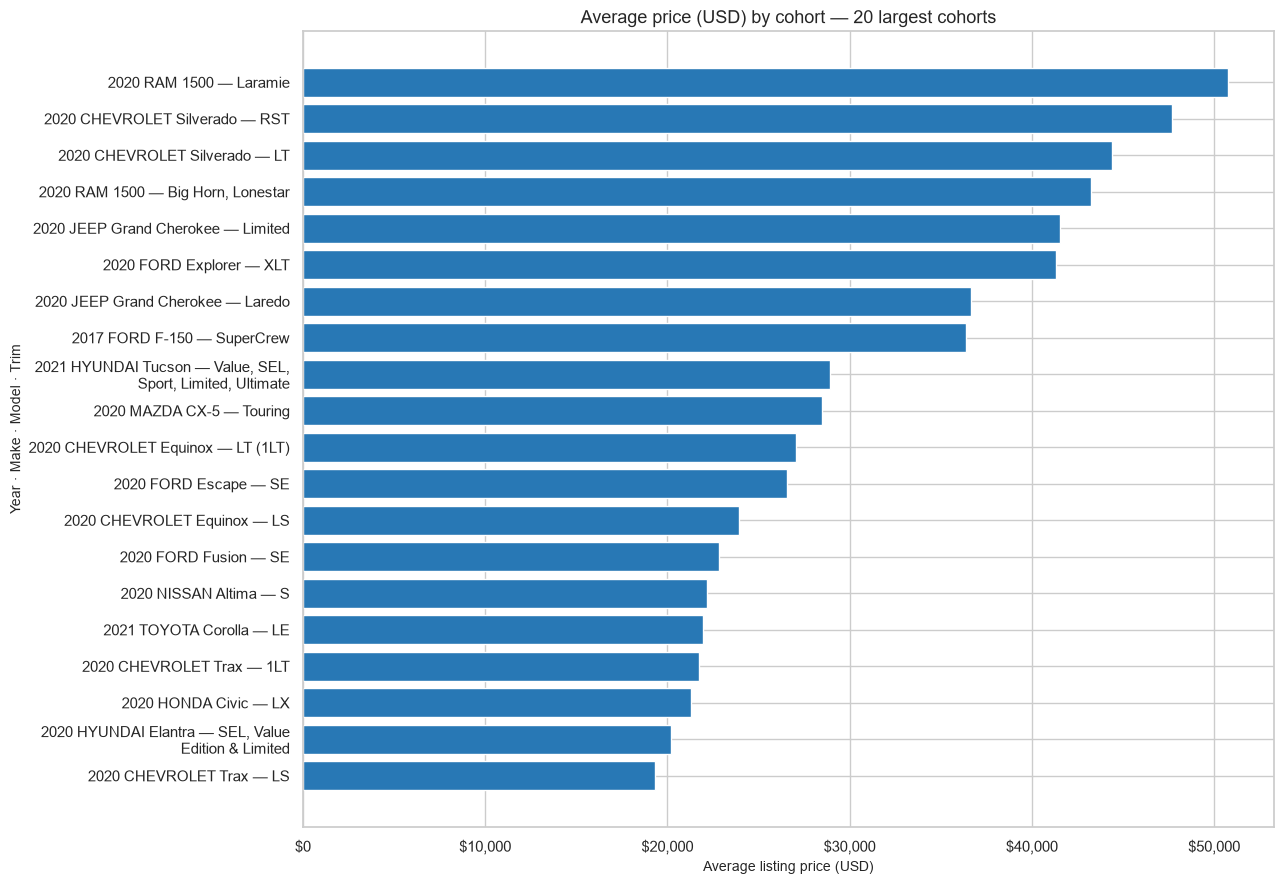

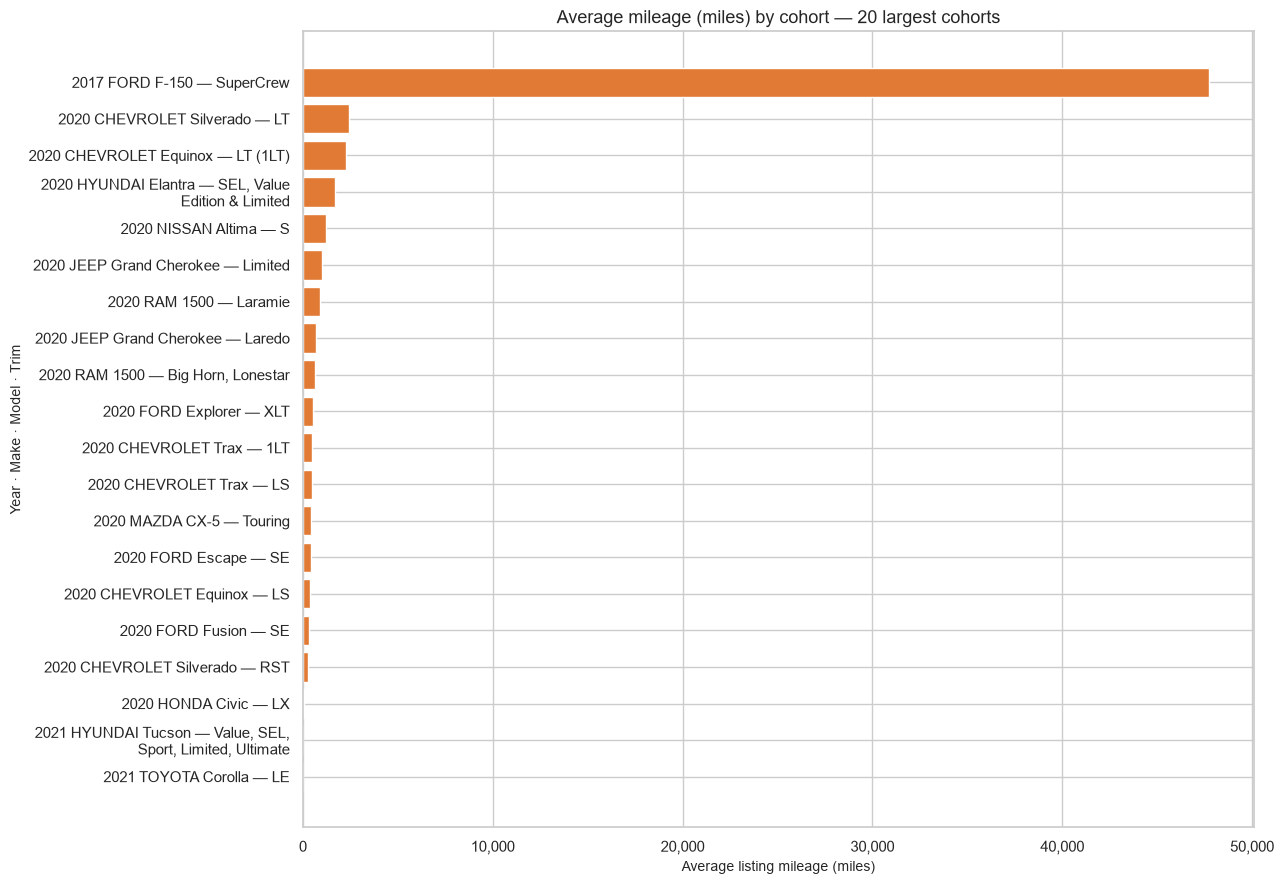

In [41]:
# Existing cohort views: average price and average mileage for the 20 largest cohorts.
top_cohorts = cohort_averages.sort("Listing count", descending=True).head(20).to_pandas()
top_cohorts["Cohort label"] = top_cohorts.apply(
    lambda row: f"{row['Year']} {row['Make']} {row['Model']} — {row['Trim']}".replace("None", "Unknown"), axis=1
).str.wrap(38)
for measure, unit, color, formatter in [
    ("Average price (USD)", "Average listing price (USD)", "#2878B5", "${:,.0f}"),
    ("Average mileage (miles)", "Average listing mileage (miles)", "#E07A35", "{:,.0f}"),
]:
    plot_data = top_cohorts.sort_values(measure, ascending=True)
    fig, ax = plt.subplots(figsize=(13, 9))
    ax.barh(plot_data["Cohort label"], plot_data[measure], color=color)
    ax.set(title=f"{measure} by cohort — 20 largest cohorts", xlabel=unit, ylabel="Year · Make · Model · Trim")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _, fmt=formatter: fmt.format(value)))
    plt.tight_layout(); plt.show()


## References

- [NIST/SEMATECH e-Handbook: Exploratory Data Analysis](https://www.itl.nist.gov/div898/handbook/eda/eda.htm) — EDA as a way to reveal data structure, anomalies, and assumptions.
- [pandas: Essential basic functionality](https://pandas.pydata.org/docs/user_guide/basics.html) — descriptive summaries for numeric and nonnumeric data.
- Project-specific field meanings and source grain: [`DATA_DICTIONARY.md`](../DATA_DICTIONARY.md).
